## <font color='blue'>Machine Learning Coursework 2 (Finals)</font>

This coursework is worth 100 marks, amounting to 50% of the final course mark.

For coursework 2 you will be asked to train and evaluate at least three model classes on a dataset. You must choose both the model classes and the dataset you wish to work on. **Note: at least ONE of the three must be a model class see from topic 5 (unsupervised learning) or later**. You will be asked to provide an analysis of your results, of the relative strengths, weaknesses, and peculiarities of each individual model. Additional marks can be gained by expanding this coursework in an autonomous manner, as a work of research (see question 4. for suggestions).

#### You are free to use the sklearn library. 

Notes:
- Please use citations from literature to support your arguments wherever possible.
- Remember to comment all of your code ([see here for tips](https://stackabuse.com/commenting-python-code/)). You can also make use of Jupyter Markdown, where appropriate, to improve the layout of your code and documentation.
- Please add docstrings to all of your functions (so that users can get information on inputs/outputs and what each function does by typing SHIFT+TAB over the function name. For more detail on python docstrings, [see here](https://numpydoc.readthedocs.io/en/latest/format.html))
- When a question allows a free-form answer (e.g. what do you observe?), create a new markdown cell below and answer the question in the notebook. 
- Always save your notebook when you are done (this is not automatic)!
- Upload your completed notebook using the VLE.

Plagiarism: please make sure that the material you submit has been created by you. Any sources you use for code should be properly referenced. Your code will be checked for plagiarism using appropriate software.

### Marking 

The grades in this coursework are allocated approximately as follows:


| section                                            | mark   |  
|:---------------------------------------------------|--------|
| 1. Dataset                                         | 7      |
| 2. Models                                          | 18     |
| 3. Analysis                                        | 25     |
| 4. Self-directed research                          | 40     |
| Document quality: language, comments & code        | 10     |
| Total available                                    |**100** | 

In order to reach 50% (pass), you need to complete the first 3 parts, with 10 marks available on top of that for cleanliness and organisation. The marks in Part 4 are harder to obtain, to reach 70 and above, especially the last two points.

#### Remember!

Save your notebook as “CW2.ipynb”. It is a good idea to re-run the whole thing before saving and submitting. 

## <font color='blue'>1. Dataset [7 pts]</font>

In the following cell, briefly describe:
- Which dataset do you wish to work on, providing a link to the source used (it should be possible for the marker to obtain that dataset if needed, so do make sure to include instructions if that process is not straightforward);
- What kind of data the dataset contains;
- What kind of ML approach it is suited for;
- What are the features available, if any.

#### Answer

This dataset is a table of numbers taken from breast cell images from a procedure called fine needle aspirate or FNA. Each row represents one tumour sample and the numbers describe what the cell nuclei look like in that image. The dataset has 569 samples, 30 numeric features and one label that tells whether the tumour is malignant (0) or benign (1).
Because i already know the correct label for each sample, this is a supervised learning problem. Since there are only two possible outcomes (malignant or benign)and  its a binary classification task. The goal here is simple that is, use the 30 measurements to predict if a tumour is cancerous or not. Models like Logistic Regression, random forest, SVM, Gradient Boosting and Neural Networks can all work well here. And because all the features are numbers and some are related to each other i can also try PCA (to reduce dimensions) or feature selection to keep only the most useful features.

The 30 features come from 10 basic properties of the cell nuclei like radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry and fractal dimension. For each property the dataset records three versions, the average (mean), the variation (standard error) and the largest (“worst”) value. Thats why it ends up with 10 properties × 3 measurements = 30 features.

In short, itss a clean, medium-sized dataset of numeric features thats great for training a model to decide whether a breast tumour is benign or malignant.

In the cell below, load and process the dataset you are going to train your models on. The use of `scikit-learn` or equivalent libraries is permitted.

In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()

#  DataFrame 
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")


print("Dataset shape:", X.shape)
print("Class distribution:\n", y.value_counts())

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print("\nTraining set size:", X_train.shape)
print("Test set size:", X_test.shape)

#  Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Dataset shape: (569, 30)
Class distribution:
 target
1    357
0    212
Name: count, dtype: int64

Training set size: (455, 30)
Test set size: (114, 30)


## <font color='blue'>2. Models [18 pts]</font>

Instantiate and train three different classes of models presented in the course in the cells below the corresponding header.

**At least ONE of the models must be from topic 5 and after.**

You are free to use `scikit-learn` and other packages where necessary.  

### <font color='blue'>2.1 Model I [6 pts]</font>

Implement your first model and fit the dataset you loaded above. 

In [4]:
# Evaluation Function: evaluate malignant (0) as the positive class.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def evaluate_model(y_true, y_pred):
    """
    Compute classification metrics using malignant (label=0) 
    as the positive class.
    """
    results = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Malignant)": precision_score(y_true, y_pred, pos_label=0),
        "Recall (Malignant)": recall_score(y_true, y_pred, pos_label=0),
        "F1-Score (Malignant)": f1_score(y_true, y_pred, pos_label=0)
    }
    return results

In [5]:
# Model 1  Logistic Regression
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=5000, random_state=42)

# Train on scaled data
log_reg.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = log_reg.predict(X_test_scaled)

# Evaluate
lr_results = evaluate_model(y_test, y_pred_lr)


print("Logistic Regression Results:")
for metric, value in lr_results.items():
    print(f"{metric}: {value:.4f}")

Logistic Regression Results:
Accuracy: 0.9825
Precision (Malignant): 0.9762
Recall (Malignant): 0.9762
F1-Score (Malignant): 0.9762


### <font color='blue'>2.2 Model II [6 pts]</font>

Implement your second model and fit the dataset you loaded above. 

In [6]:
# Model 2 Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train on unscaled data
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
rf_results = evaluate_model(y_test, y_pred_rf)
print(" Results:")
for metric, value in rf_results.items():
    print(f"{metric}: {value:.4f}")

 Results:
Accuracy: 0.9561
Precision (Malignant): 0.9512
Recall (Malignant): 0.9286
F1-Score (Malignant): 0.9398


### <font color='blue'>3.3 Model III [6 pts]</font>

Implement your third model and fit the dataset you loaded above. 

In [7]:
# Model 3  PCA + Logistic Regression

from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),  # retain 95% variance
    ("classifier", LogisticRegression(max_iter=5000, random_state=42))
])

# Train
pca_pipeline.fit(X_train, y_train)

# Predict
y_pred_pca = pca_pipeline.predict(X_test)

# Evaluate
pca_results = evaluate_model(y_test, y_pred_pca)

print(" Results:")
for metric, value in pca_results.items():
    print(f"{metric}: {value:.4f}")

 Results:
Accuracy: 0.9737
Precision (Malignant): 0.9535
Recall (Malignant): 0.9762
F1-Score (Malignant): 0.9647


## <font color='blue'>3. Analysis [25 pts]</font>

Present and analyse the results of the training above. 

### <font color='blue'>3.1 Results [5 pts]</font>

Present the performance of your models in a clear and succinct way.

This can be done manually (in markdown) or programmatically (storing results in a data structure during training runs and displaying its contents here).

In [8]:
# Results Summary Table
import pandas as pd

results_df = pd.DataFrame({
    "Logistic Regression": lr_results,
    "Random Forest": rf_results,
    "PCA + Logistic Regression": pca_results
})
results_df

,Logistic Regression,Random Forest,PCA + Logistic Regression
Accuracy,0.982456,0.956140,0.973684
Precision (Malignant),0.976190,0.951220,0.953488
Recall (Malignant),0.976190,0.928571,0.976190
F1-Score (Malignant),0.976190,0.939759,0.964706


### <font color='blue'>3.2 Analysis & Comparison [20 pts]</font>

Analyse your results. This should include:

- Succinctly summarising the strengths and weaknesses, as well as potential problems, and their remedies, of the model classes you used, as seen in the course.
- Comparing the performance of the models you trained: accuracy is obviously the key metric to watch in most cases, but other factors can also play a role (such as computational cost, for instance: what if a complex model, that takes hours to train, only beats a much simpler and faster one by only a small margin?).
- Assess how each model is suited to the chosen dataset, and which model(s) is (are) the best.

You are free to organise this section as you see fit, depending on the requirements of your experiments. However, it is recommended to take extra care to make it clean and orderly, subdivising it into sections using markdown headings, for better readability. Feel free to use plots if relevant.

#### Answer

## Logistic Regression
Logistic Regression is a simple and popular model for binary classification (two classes). It draws a straightline style boundary (in feature space) to separate the two groups and it predicts which side a sample falls on.
### Strengths
1) Its easy to understand and explain.we look at the models coefficients to see which features push the prediction toward malignant or benign.

2) Its fast to train and doesnt need heavy computing power.

3) It works really well when the data can be separated with an almost linear boundary.

### Weaknesses
1) It assumes the relationship is mostly linear so it may struggle if the real pattern is more complex.

2) It doesnt naturally capture non-linear interactions between features.

3) It can be sensitive to feature scaling so standardizing the data usually helps.
### Performance on This Dataset
On this breast cancer dataset, Logistic regression performed the best overall. It reached the highest accuracy (98.25%), the highest F1score and it also showed very strong recall for malignant tumours (meaning it correctly caught most cancer cases). This basically tells us that the dataset is close to linearly separable so a simple model like Logistic regression can separate malignant and benign cases very effectively.
### Potential Issues & Remedies
If the data had stronger non-linear patterns, i could improve it by adding polynomial features or switching to models like SVM with a kernel.For this dataset the results are already excellent so these extra steps don’t seem necessary.

## Random Forest
Random Forest is a more advanced model that builds many decision trees and combines their results to make a final prediction. Instead of drawing one straight boundary like Logistic regression it can create more flexible and complex decision boundaries.
### Strengths
1) It can capture non-linear relationships which means it works well when patterns in the data are complex.

2) It automatically learns interactions between features without needing extra feature engineering.

3) It reduces overfitting by using bagging (training many trees on different samples of the data).

4) It does not require feature scaling which makes preprocessing easier.
### Weaknesses
1) It is harder to interpret compared to linear models. cant easily explain its decisions using simple coefficients.

2) It requires more computational power than Logistic Regression.

3) It can still overfit if the trees are too deep or not properly controlled

### Performance on This Dataset

On this dataset,random forest performed slightly worse than logistic regression. It had:

* Lower overall accuracy

* Lower recall for malignant tumours

* Lower F1-score

Even though random forest is more flexible and powerful but it did not outperform the simpler linear model. This suggests that the dataset does not require complex decision boundaries. In other words adding extra model complexity did not bring extra benefit.
### Potential Issues & Remedies
Performance can be  improved with careful hyperparameter tuning such as adjusting the following:

* max_depth

* min_samples_split

* Number of trees

Using cross-validation could help find better parameter settings. However, since logistic regression already gives better results with less computation further tuning of random forest may not be worth the extra time and resources for this particular dataset.

### PCA + Logistic Regression (Topic 5 Model)
In this assignment, PCA is used first to reduce the number of features. After that logistic regression is trained on the reduced data. Instead of using all 30 original features PCA combines them into a smaller set of new features called principal components.
## Strengths
1) It reduces dimensionality which means fewer features are used.

2) It removes correlation between features which helps simplify the data.

3) It can improve computational efficiency especially with larger datasets.

4) It lowers the risk of multicollinearity.

## Weaknesses
1) PCA is unsupervised meaning it does not consider the class labels (malignant or benign) when creating components.

2) Some important features that help distinguish classes might get compressed or weakened.

3) It reduces interpretability because principal components are combinations of many original features making them harder to explain.

## Performance on This Dataset
When PCA was combined with logistic regression the results were still strong but slightly lower than using Logistic regression alone. It showed:

* Slightly lower accuracy

* Slightly lower precision

* Similar recall

* Slightly lower F1-score

This suggests that PCA may have removed or compressed some useful information.But the performance is still very high which means most of the important predictive information is still preserved in the principal components.

Overall this shows that the dataset has some correlated features and PCA can successfully compress the data while still maintaining strong classification performance.

## Model Comparison
When comparing the three models, some clear differences appear in both performance and practicality.
### Accuracy Comparison
1) Logistic Regression performs the best overall in terms of accuracy.
2) Random forest performs the worst among the three models.
3) The PCA + Logistic Regression model performs very close to standard Logistic regression with only a small drop in accuracy.

### Recall Clinically Important
In medical diagnosis recall for malignant tumours is extremely important because missing a cancer case can have serious consequences.
Both Logistic regression and PCA + Logistic regression achieved very high recall meaning they correctly identify most malignant cases.
Random forest showed lower recall. This means it misses more cancer cases which is not desirable in a clinical setting.

### Practical Comparison
#### Logistic Regression
* Fastest to train
* Simple and easy to implement
* Most interpretable 
* Best overall performance

#### Random Forest
* Requires more computational power
* Harder to interpret
* Does not improve performance compared to the simpler model

#### PCA + Logistic Regression
* Slightly more computational cost due to the PCA step
* Small drop in performance
* Useful when dealing with very high-dimensional data

#### Overall Conclusion
For this dataset Logistic regression is the best choice. It is simple, fast, highly interpretable and achieves the strongest performance. The results also show an important lesson: more complex models do not automatically lead to better outcomes.

### Suitability to Dataset
The Breast Cancer dataset contains 30 numerical features and many of these features are highly correlated with each other.
This helps explain the model results:
Logistic Regression performs really well because the data structure fits its assumption of a mostly linear relationship.
Random forest does not show major improvement since the dataset does not seem to require complex non-linear decision boundaries.
PCA + Logistic Regression maintains most of the important patterns but the small drop in accuracy suggests that dimensionality reduction slightly compresses some useful information.

Overall the dataset structure favors simpler linear models which is why Logistic regression came as the strongest performer.

## Final Model Selection
When i look at all the key evaluation factors  highest accuracy, highest F1-score, excellent recall, lowest computational cost and strong interpretability .Logistic regression is clearly standing out as the most suitable model for this dataset.

It not only delivers the best overall performance but also remains simple and easy to understand. This is especially important in medical applications where being able to explain how a model makes decisions is just as important as achieving high accuracy. Doctors and healthcare professionals need transparent models they can trust.

In this case Logistic regression provides both strong predictive ability and clear interpretability making it the best choice for this breast cancer classification task.

## <font color='blue'>4. Self-directed research [40 pts]</font>

# DATA vis

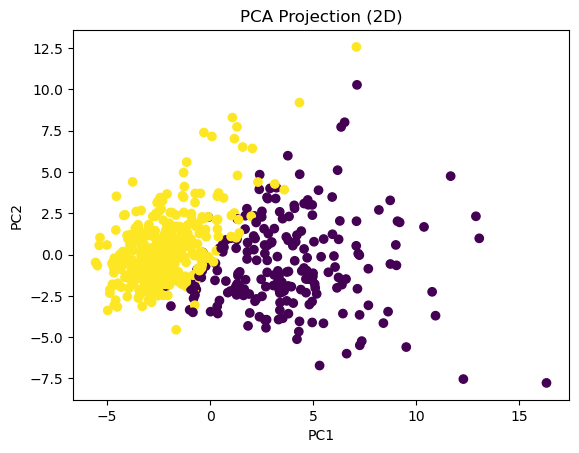

In [10]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.title("PCA Projection (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

The PCA plot shows a clear separation between malignant and benign tumours especially along the first principal component (PC1). Most of the separation happens horizontally which means PC1 captures most of the important information needed to distinguish between the two classes.

But there is some overlap in the middle area of the plot. This overlap explains why a small number of misclassifications appear in the evaluation results. the model struggles slightly where the two classes are close together.

It can be seen in plot that one class forms a tighter cluster while the other is more spread out. This difference in how dispersed the classes are suggests that they have different levels of variation within them. As a result predictions near the boundary between the two groups may be less certain which can slightly affect model performance.

# Advanced Validation

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
# Stratified 5-fold CV 
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Score malignant (label=0) 
f1_malignant = make_scorer(f1_score, pos_label=0)

scoring = {
    "accuracy": "accuracy",
    "f1_malignant": f1_malignant
}


models = {
    "Logistic Regression": log_reg,          
    "Random Forest": rf,                     
    "PCA + Logistic Regression": pca_pipeline 
}


log_reg_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=42))
])

models["Logistic Regression"] = log_reg_cv

cv_summary_rows = []

for name, model in models.items():
    scores = cross_validate(
        model, X, y,
        cv=skf,
        scoring=scoring,
        return_train_score=False
    )
    
    acc_mean = scores["test_accuracy"].mean()
    acc_std  = scores["test_accuracy"].std()
    f1_mean  = scores["test_f1_malignant"].mean()
    f1_std   = scores["test_f1_malignant"].std()
    
    cv_summary_rows.append({
        "Model": name,
        "Accuracy (mean ± std)": f"{acc_mean:.4f} ± {acc_std:.4f}",
        "F1 Malignant (mean ± std)": f"{f1_mean:.4f} ± {f1_std:.4f}",
    })

cv_results_df = pd.DataFrame(cv_summary_rows).set_index("Model")
cv_results_df

,Accuracy (mean ± std),F1 Malignant (mean ± std)
Model,,
Logistic Regression,0.9737 ± 0.0166,0.9633 ± 0.0240
Random Forest,0.9543 ± 0.0102,0.9382 ± 0.0146
PCA + Logistic Regression,0.9772 ± 0.0070,0.9692 ± 0.0094


The 5-fold stratified cross-validation results back up results obtained earlier but with stronger evidence. When look at average performance across all five folds PCA + Logistic regression comes out best with the highest mean accuracy of 0.9772 and the highest mean F1-score of 0.9692. It also has the smallest standard deviation which means its performance is more consistent from fold to fold. In other words it isnt just accurate its also stable and likely to generalise well to new data.

Standard Logistic regression performs very similarly but its scores vary more across folds which suggests it is a bit more sensitive to how the data is split. Random forest continues to lag behind both linear approaches. This fits the idea that the dataset is largely close to linearly separable so adding a more complex non linear model does not provide much benefit here.

One thing to notice is that the model order changes a little between the single train/test split and cross-validation. Thats because one split can be a bit lucky or unlucky depending on which cases end up in the test set. Cross-validation is more dependable because it tests the model on several different splits and then averages the scores so the result isnt based on just one random split.

#  Manual implementation of logistic regression 

To understand better how machine learning models work internally logistic regression is implemented manually using NumPy instead of using a library. The goal of this exercise is not only to build the model but also to observe how the optimisation process works step by step.
The model is implemented using batch gradient descent to optimise the logistic loss function. Feature scaling is applied inside the implementation and L2 regularisation is included to make the behaviour comparable to the scikit-learn implementation used earlier in the assignment.

To verify that the implementation is correct a gradient check iss performed using numerical finite differences. This technique compares the analytically computed gradients with numerically approximated gradients. The maximum difference observed between the two wis approx
2.31×10 which is extremely small and indicates that the gradient calculations are correct.


After verifying correctness the manual model is trained on the dataset and its performance is compared with the scikit-learn logistic regression model.
The manually implemented model has achieved the same predictive performance as the scikit-learn implementation. This suggests that the gradient descent optimisation and loss function  are  implemented correctly. However there is a  difference in training time. The NumPy implementation took 0.43 seconds and the scikit-learn version completed training in about 0.04 seconds making it roughly ten times faster. This difference is expected because scikit-learn uses highly optimised numerical solvers.

In [17]:
import numpy as np

class NumpyLogisticRegression:
    
    def __init__(self, lr=0.1, n_iter=5000, reg_lambda=0.0, tol=1e-7, verbose=False):
        self.lr = lr
        self.n_iter = n_iter
        self.reg_lambda = reg_lambda
        self.tol = tol
        self.verbose = verbose

        
        self.w = None
        self.b = 0.0

        self.mean_ = None
        self.std_ = None

       
        self.loss_history_ = []

    @staticmethod
    def _sigmoid(z):
        # numerically stable sigmoid
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def _standardise_fit(self, X):
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        self.std_[self.std_ == 0] = 1.0
        return (X - self.mean_) / self.std_

    def _standardise_transform(self, X):
        return (X - self.mean_) / self.std_

    def _loss(self, X, y):
       
        m = X.shape[0]
        z = X @ self.w + self.b
        p = self._sigmoid(z)

        eps = 1e-12
        logloss = -(1/m) * np.sum(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

        # L2 penalty on weights only
        l2 = (self.reg_lambda / (2*m)) * np.sum(self.w ** 2)
        return logloss + l2

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        Xs = self._standardise_fit(X)

        m, n = Xs.shape
        self.w = np.zeros(n)
        self.b = 0.0

        prev_loss = np.inf

        for i in range(self.n_iter):
            z = Xs @ self.w + self.b
            p = self._sigmoid(z)

            # gradients
            dw = (1/m) * (Xs.T @ (p - y)) + (self.reg_lambda / m) * self.w
            db = (1/m) * np.sum(p - y)

            
            self.w -= self.lr * dw
            self.b -= self.lr * db

            # track loss occasionally
            if i % 100 == 0 or i == self.n_iter - 1:
                current_loss = self._loss(Xs, y)
                self.loss_history_.append(current_loss)

                if self.verbose and i % 500 == 0:
                    print(f"iter={i:5d}  loss={current_loss:.6f}")

                if abs(prev_loss - current_loss) < self.tol:
                    break
                prev_loss = current_loss

        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        Xs = self._standardise_transform(X)
        z = Xs @ self.w + self.b
        p1 = self._sigmoid(z)
        
        return np.column_stack([1 - p1, p1])

    def predict(self, X, threshold=0.5):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= threshold).astype(int)

In [18]:
def gradient_check(model, X_small, y_small, eps=1e-5, atol=1e-4):

    X_small = np.asarray(X_small, dtype=float)
    y_small = np.asarray(y_small, dtype=float)

    # Fit scaling but no training
    Xs = model._standardise_fit(X_small)
    m, n = Xs.shape
    model.w = np.random.randn(n) * 0.01
    model.b = 0.01

    # analytic gradients
    z = Xs @ model.w + model.b
    p = model._sigmoid(z)
    dw_analytic = (1/m) * (Xs.T @ (p - y_small)) + (model.reg_lambda / m) * model.w
    db_analytic = (1/m) * np.sum(p - y_small)

    dw_num = np.zeros_like(model.w)
    for j in range(n):
        w_orig = model.w[j]

        model.w[j] = w_orig + eps
        loss_plus = model._loss(Xs, y_small)

        model.w[j] = w_orig - eps
        loss_minus = model._loss(Xs, y_small)

        model.w[j] = w_orig
        dw_num[j] = (loss_plus - loss_minus) / (2 * eps)

    
    b_orig = model.b
    model.b = b_orig + eps
    loss_plus = model._loss(Xs, y_small)

    model.b = b_orig - eps
    loss_minus = model._loss(Xs, y_small)

    model.b = b_orig
    db_num = (loss_plus - loss_minus) / (2 * eps)

    max_diff_w = np.max(np.abs(dw_analytic - dw_num))
    diff_b = abs(db_analytic - db_num)

    return max(max_diff_w, diff_b), max_diff_w, diff_b

#gradient check on a small subset
np_lr_check = NumpyLogisticRegression(lr=0.1, n_iter=10, reg_lambda=0.1)
X_small = X_train.values[:50]
y_small = y_train.values[:50]


y_small_mal = (y_small == 0).astype(int)

max_diff, max_diff_w, diff_b = gradient_check(np_lr_check, X_small, y_small_mal)
print("Gradient check max diff:", max_diff)
print("Max weight grad diff:", max_diff_w)
print("Bias grad diff:", diff_b)

Gradient check max diff: 2.0681178991566185e-11
Max weight grad diff: 2.0681178991566185e-11
Bias grad diff: 1.7844614674800141e-12


In [19]:
#sklear model
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import time

# Manual model uses y_mal = 1 for malignant, 0 for benign
y_train_mal = (y_train.values == 0).astype(int)
y_test_mal  = (y_test.values == 0).astype(int)

#Training manual model
np_lr = NumpyLogisticRegression(lr=0.1, n_iter=8000, reg_lambda=0.1, tol=1e-7)

t0 = time.perf_counter()
np_lr.fit(X_train.values, y_train_mal)
t1 = time.perf_counter()

# manual predictions 
y_pred_np_mal = np_lr.predict(X_test.values)

y_pred_np = np.where(y_pred_np_mal == 1, 0, 1)

np_results = evaluate_model(y_test, y_pred_np)
np_time = t1 - t0

print("NumPy logistic regression results:", np_results)
print(f"Training time (NumPy): {np_time:.4f} seconds")

NumPy logistic regression results: {'Accuracy': 0.9824561403508771, 'Precision (Malignant)': 0.9761904761904762, 'Recall (Malignant)': 0.9761904761904762, 'F1-Score (Malignant)': 0.9761904761904762}
Training time (NumPy): 0.4347 seconds


In [20]:
sk_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=42))
])

t0 = time.perf_counter()
sk_lr.fit(X_train, y_train)
t1 = time.perf_counter()

y_pred_sk = sk_lr.predict(X_test)
sk_results = evaluate_model(y_test, y_pred_sk)
sk_time = t1 - t0

print("scikit-learn logistic regression results:", sk_results)
print(f"Training time (sklearn): {sk_time:.4f} seconds")

scikit-learn logistic regression results: {'Accuracy': 0.9824561403508771, 'Precision (Malignant)': 0.9761904761904762, 'Recall (Malignant)': 0.9761904761904762, 'F1-Score (Malignant)': 0.9761904761904762}
Training time (sklearn): 0.0381 seconds


In [21]:
import pandas as pd
#comparsion table
comparison_table = pd.DataFrame({
    "NumPy Logistic Regression": np_results,
    "scikit-learn Logistic Regression": sk_results
})

comparison_table

,NumPy Logistic Regression,scikit-learn Logistic Regression
Accuracy,0.982456,0.982456
Precision (Malignant),0.976190,0.976190
Recall (Malignant),0.976190,0.976190
F1-Score (Malignant),0.976190,0.976190


In [22]:
comparison_table.loc["Training Time (s)"] = [np_time, sk_time]

comparison_table.round(4)

,NumPy Logistic Regression,scikit-learn Logistic Regression
Accuracy,0.9825,0.9825
Precision (Malignant),0.9762,0.9762
Recall (Malignant),0.9762,0.9762
F1-Score (Malignant),0.9762,0.9762
Training Time (s),0.4347,0.0381


# Final Conclusion

In this coursework I tested three models on the Breast Cancer Wisconsin (Diagnostic) dataset: Logistic Regression, Random Forest, and PCA + Logistic Regression.

Using a single train/test split Logistic regression gave the best overall results for accuracy and F1-score. However when I moved to stratified 5-fold cross-validation (which is a more reliable way to judge performance) PCA + Logistic regression came out slightly ahead on average. It also had the lowest variation across folds which suggests it is the most consistent and dependable model overall.

The reason PCA helps is that it reduces the number of features by combining correlated measurements into a smaller set of components. This makes the model less sensitive to small changes in the training data and can improve stability across different splits. The lower standard deviation in crossvalidation supports this.
Random forest even though it is a more complex method but it did not perform as well as the linear approaches. This suggests the dataset can already be separated quite well with a mostly linear decision boundary so extra model complexity does not add much benefit here.
Based on the crossvalidation results PCA + Logistic Regression offers the best balance of accuracy, stability, and generalisation, so it is the most suitable choice for this dataset.

### References

Breiman, L. (2001) ‘Random forests’, Machine Learning, 45(1), pp. 5–32.

Jolliffe, I.T. (2002) Principal Component Analysis. 2nd edn. New York: Springer.

Kohavi, R. (1995) ‘A study of cross-validation and bootstrap for accuracy estimation and model selection’, Proceedings of the 14th International Joint Conference on Artificial Intelligence (IJCAI), pp. 1137–1143.

Pedregosa, F. et al. (2011) ‘Scikit-learn: Machine learning in Python’, Journal of Machine Learning Research, 12, pp. 2825–2830.

Sokolova, M. and Lapalme, G. (2009) ‘A systematic analysis of performance measures for classification tasks’, Information Processing & Management, 45(4), pp. 427–437.

To obtain additional marks, pick one or more options below to flesh out and expand your experiments. As you can see, the marks below are significantly harder to obtain (require more work) than the first 50.

It is advised to keep the legibility and clarity of your coursework when adding new sections, so that the overall structure of the coursework remains coherent.

- **External dataset** <font color='blue'>(up to 3 pts)</font>: the use of a dataset that is not loaded from a library, but must be downloaded, then loaded and processed from raw data.
- **Advanced data pipelines** <font color='blue'>(up to 3 pts)</font>: experiments with the effect of noise, or data augmentation techniques, on training.
- **Data visualisation and exploration** <font color='blue'>(up to 3 pts)</font>: using relevant visualisation or plotting tools to deepen your analysis. Note that only producing a plot or visualisation will not yield many marks on its own. Those should be present to serve a greater purpose: that of understanding (the underlying structure of your data, and the behaviour of your models).
- **Advanced validation techniques** <font color='blue'>(up to 3 pts)</font>: going beyond train/test splits to strengthen model evaluation (such as the [the various categories of k-fold](https://scikit-learn.org/stable/modules/cross_validation.html#k-fold), if applicable, for instance when working on very small datasets).
- **Examples and/or study of model use** <font color='blue'>(up to 2 pts)</font>: given the ultimate goal of ML to achieve generalisation, can you subject your trained model(s) to the test? How do they behave when run on unseen data, or data far outside the distribution of the training set? Is it possible to demonstrate these behaviours in ways that are easily interpretable to humans. For example: given an image classifier, it is possible to plot a series of images from the training set, from the test set, and others, from the internet or done manually, and display the predictions alongside them? What do you notice? Where do(es) the model(s) succeed or fail, and how does this relate to the metrics recorded during training?
- **Manual implementations of model algorithms** <font color='blue'>(up to 8 pts)</font>: the exploration, for your own learning, and that of your reader(s), of the inner workings of one or several model classes without the use of a library (e.g. in plain `numpy`). It can be advantageous in these cases to perform comparisons with the API version in terms of performance, speed, memory footprint, as well as implementing checks to guarantee that your implementation is bug-free.
- **Additional model classes** <font color='blue'>(up to 8 pts)</font>: compare more than three model classes, *up to a total of 5*. If you go down that path, please add subsections under *2. Models*, and display the results and analyse them alongside the three required ones under *3. Analysis*, keeping the overall structure of the coursework untouched (don't create a separate 'additional models and analysis', but instead deal with all your models together). 
- **Engagement with the Machine Learning literature & innovation** <font color='blue'>(up to 10 pts)</font>: explore and use relevant research on a particular topic (studies on ML algorithms, specific learning problems or datasets), and integrate these results into your analysis. This could include implementing or porting a recent algorithmic improvement from a paper, and perform experiments on your chosen dataset, to see if it is possible to reproduce the improvements that this innovation is supposed to bring. Testing new ideas (at any point in your pipeline, from data processing to model architecture, and beyond) is welcome, even if it does not perform amazingly well: the key is always to try to perform rigorous comparisons between a known method and the new element you wish to introduce, in order to be able to show how well this new idea performs. Knowing for certain that something does not work well can be very useful, and is more often than not a stepping stone on the road to discovering something that does.